# Model 1 of 5 — Cell Classification: CNN vs Vision Transformer
**Hematological AI Decision Support System — MSc Biotechnology, VIT**

**Goal:** Classify WBC subtypes (neutrophil, lymphocyte, monocyte, eosinophil, basophil) and compare CNN (transfer learning) vs ViT (fine-tuning) head-to-head, with Grad-CAM explainability.

**Dataset:** PBC Dataset (Barcelona) — public, pre-labeled, ~17,000 images across 8 classes (grouped to 5 WBC types for this study; extra classes like IG, platelets, erythroblasts are noted in limitations).

**Pipeline stage:** Model 1 of 5. Its trained CNN weights get reused as the classifier for Model 4 (GAN).

> **Runtime Notice:** Run this top-to-bottom in Google Colab with a **GPU runtime** (*Runtime → Change runtime type → T4 GPU or A100*).


In [ ]:
# 1. Environment setup
!pip install -q timm torchmetrics grad-cam kagglehub

import os, random, time, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
import timm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.6 MB/s eta 0:00:00
Device: cuda


## 2. Dataset — PBC (Barcelona) via KaggleHub
We download the 8-class Peripheral Blood Cell (PBC) dataset via `kagglehub`. We isolate and map the 5 canonical WBC subtypes (Neutrophils, Lymphocytes, Monocytes, Eosinophils, and Basophils) while setting aside non-target cells.


In [ ]:
# 3. Download dataset
import kagglehub

# Download PBC dataset (8 classes: basophil, eosinophil, erythroblast, ig, lymphocyte, monocyte, neutrophil, platelet)
path = kagglehub.dataset_download("unclesamulus/blood-cells-image-dataset")
print("Dataset downloaded to:", path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level < 2:
        print('  ' * level + os.path.basename(root) + f"  ({len(files)} files)")


100%|██████████| 268M/268M [00:02<00:00, 95.7MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/unclesamulus/blood-cells-image-dataset/versions/2
2  (0 files)
  bloodcells_dataset  (0 files)


In [ ]:
# 4. Build file list + labels
import glob
from pathlib import Path
from collections import Counter

DATA_ROOT = Path(path)

# Locate image directory
class_dirs = [d for d in DATA_ROOT.rglob('*') if d.is_dir() and any(f.suffix.lower() in ['.jpg','.jpeg','.png'] for f in d.glob('*'))]
print("Found class folders:")
for d in class_dirs:
    n = len(list(d.glob('*')))
    print(f"  {d.name}: {n} images")

TARGET_CLASSES = ['neutrophil', 'lymphocyte', 'monocyte', 'eosinophil', 'basophil']
samples = []

for d in class_dirs:
    cls_name = d.name.lower()
    if cls_name in TARGET_CLASSES:
        for f in d.glob('*'):
            if f.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                samples.append((str(f), TARGET_CLASSES.index(cls_name)))

print(f"\nTotal usable samples across {len(TARGET_CLASSES)} classes: {len(samples)}")
counts = Counter([s[1] for s in samples])
for i, c in enumerate(TARGET_CLASSES):
    print(f"  {c}: {counts.get(i,0)}")


Found class folders:
  eosinophil: 3117 images
  neutrophil: 3329 images
  erythroblast: 1551 images
  lymphocyte: 1214 images
  ig: 2895 images
  platelet: 2348 images
  basophil: 1218 images
  monocyte: 1420 images

Total usable samples across 5 classes: 10298
  neutrophil: 3329
  lymphocyte: 1214
  monocyte: 1420
  eosinophil: 3117
  basophil: 1218


In [ ]:
# 5. Stratified Train / Val / Test split
from sklearn.model_selection import train_test_split

paths = [s[0] for s in samples]
labels = [s[1] for s in samples]

train_p, temp_p, train_l, temp_l = train_test_split(paths, labels, test_size=0.3, stratify=labels, random_state=SEED)
val_p, test_p, val_l, test_l = train_test_split(temp_p, temp_l, test_size=0.5, stratify=temp_l, random_state=SEED)

print(f"Train: {len(train_p)} | Val: {len(val_p)} | Test: {len(test_p)}")


Train: 7208 | Val: 1545 | Test: 1545


In [ ]:
# 6. Dataset class + Transforms (Augmentations: rotation, flip, crop, color jitter)
from PIL import Image

IMG_SIZE = 224

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class WBCDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        return img, self.labels[idx]

train_ds = WBCDataset(train_p, train_l, train_tfms)
val_ds   = WBCDataset(val_p, val_l, eval_tfms)
test_ds  = WBCDataset(test_p, test_l, eval_tfms)

BATCH_SIZE = 32
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## 7. Class Imbalance Handling
We apply class-weighted Cross-Entropy loss to counteract dataset imbalance (e.g., lower frequency of basophils compared to neutrophils).


In [ ]:
# 7. Compute class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.arange(len(TARGET_CLASSES)), y=train_l)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", dict(zip(TARGET_CLASSES, class_weights.cpu().numpy().round(2))))


Class weights: {'neutrophil': np.float32(0.62), 'lymphocyte': np.float32(1.7), 'monocyte': np.float32(1.45), 'eosinophil': np.float32(0.66), 'basophil': np.float32(1.69)}


## 8. Model A — CNN (EfficientNetB0)
Two-phase training approach:
1. **Phase 1:** Freeze backbone, train classification head.
2. **Phase 2:** Unfreeze backbone, fine-tune end-to-end with low learning rate.


In [ ]:
# 8a. Build EfficientNetB0
def build_cnn(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_feats = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_feats, num_classes)
    return model

cnn_model = build_cnn(len(TARGET_CLASSES)).to(device)

for name, param in cnn_model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

print("Trainable params (Phase 1):", sum(p.numel() for p in cnn_model.parameters() if p.requires_grad))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.5MB/s]


Trainable params (Phase 1): 6405


In [ ]:
# 8b. Modular Training Loop
from tqdm.auto import tqdm

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(is_train):
        for x, y in tqdm(dataloader, leave=False):
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

def train_model(model, train_dl, val_dl, epochs, lr, criterion, patience=5, ckpt_path='best_model.pt'):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc, patience_ctr = 0, 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_dl, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    return history


In [ ]:
# 8c & 8d. Train CNN (Phase 1 & Phase 2)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

print("--- CNN Phase 1: Head Training ---")
hist_p1 = train_model(cnn_model, train_dl, val_dl, epochs=6, lr=1e-3, criterion=criterion, ckpt_path='cnn_phase1.pt')

print("--- CNN Phase 2: Full Fine-tuning ---")
cnn_model.load_state_dict(torch.load('cnn_phase1.pt'))
for param in cnn_model.parameters():
    param.requires_grad = True

hist_p2 = train_model(cnn_model, train_dl, val_dl, epochs=20, lr=1e-4, criterion=criterion, patience=6, ckpt_path='cnn_best.pt')
cnn_model.load_state_dict(torch.load('cnn_best.pt'))
print("CNN training complete.")


--- CNN Phase 1: Head Training ---


  0%|          | 0/226 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

Epoch 1/6 | train_loss=1.0713 acc=0.7074 | val_loss=0.9079 acc=0.7547


  0%|          | 0/226 [00:00<?, ?it/s]

...

Epoch 11/20 | train_loss=0.2781 acc=0.9979 | val_loss=0.2716 acc=0.9981


  0%|          | 0/226 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/49 [00:00<?, ?it/s]

Epoch 12/20 | train_loss=0.2761 acc=0.9992 | val_loss=0.2726 acc=0.9974
Early stopping triggered at epoch 12
CNN training complete.


## 9. Model B — Vision Transformer (`vit_small_patch16_224`)
We use `vit_small_patch16_224` via `timm` for a fair comparison against EfficientNetB0.


In [ ]:
# 9a & 9b. Train ViT (Phase 1 & Phase 2)
vit_model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=len(TARGET_CLASSES)).to(device)

for name, param in vit_model.named_parameters():
    if 'head' not in name:
        param.requires_grad = False

print("--- ViT Phase 1: Head Training ---")
hist_vit_p1 = train_model(vit_model, train_dl, val_dl, epochs=6, lr=1e-3, criterion=criterion, ckpt_path='vit_phase1.pt')

print("--- ViT Phase 2: Full Fine-tuning ---")
vit_model.load_state_dict(torch.load('vit_phase1.pt'))
for param in vit_model.parameters():
    param.requires_grad = True

hist_vit_p2 = train_model(vit_model, train_dl, val_dl, epochs=20, lr=3e-5, criterion=criterion, patience=6, ckpt_path='vit_best.pt')
vit_model.load_state_dict(torch.load('vit_best.pt'))
print("ViT training complete.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

--- ViT Phase 1: Head Training ---


  0%|          | 0/226 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

...

  0%|          | 0/226 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/49 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

assert self._parent_pid == os.getpid(), 'can only test a child process'      self._shutdown_workers()  
     File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
     if w.is_alive(): 
     ^ ^^ ^  ^^^^^^^^^^^^^^^^^^^
^

Epoch 8/20 | train_loss=0.2713 acc=0.9981 | val_loss=0.2850 acc=0.9955
Early stopping triggered at epoch 8
ViT training complete.


## 10. Head-to-Head Evaluation & Metrics
Comparative performance metrics (Accuracy, Macro F1, Confusion Matrices, Loss/Accuracy curves).


In [ ]:
# 10a. Metrics & Classification Reports
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

@torch.no_grad()
def get_preds(model, dataloader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for x, y in dataloader:
        x = x.to(device)
        out = model(x)
        probs = torch.softmax(out, dim=1)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

cnn_labels, cnn_preds, cnn_probs = get_preds(cnn_model, test_dl)
vit_labels, vit_preds, vit_probs = get_preds(vit_model, test_dl)

print("=== CNN (EfficientNetB0) — Test Set ===")
print(f"Accuracy: {accuracy_score(cnn_labels, cnn_preds):.4f}")
print(f"Macro F1: {f1_score(cnn_labels, cnn_preds, average='macro'):.4f}")
print(classification_report(cnn_labels, cnn_preds, target_names=TARGET_CLASSES))

print("\n=== ViT (vit_small_patch16_224) — Test Set ===")
print(f"Accuracy: {accuracy_score(vit_labels, vit_preds):.4f}")
print(f"Macro F1: {f1_score(vit_labels, vit_preds, average='macro'):.4f}")
print(classification_report(vit_labels, vit_preds, target_names=TARGET_CLASSES))


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d9753f7d440>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

=== CNN (EfficientNetB0) — Test Set ===
Accuracy: 0.9935
Macro F1: 0.9917
              precision    recall  f1-score   support

  neutrophil       1.00      0.99      0.99       500
  lymphocyte       0.99      0.99      0.99       182
    monocyte       0.98      0.99      0.98       213
  eosinophil       1.00      1.00      1.00       467
    basophil       0.98      1.00      0.99       183

    accuracy                           0.99      1545
   macro avg       0.99      0.99      0.99      1545
weighted avg       0.99      0.99      0.99      1545


=== ViT (vit_small_patch16_224) — Test Set ===
Accuracy: 0.9935
Macro F1: 0.9920
              precision    recall  f1-score   support

  neutrophil       0.99      0.99      0.99       500
  lymphocyte       0.98      0.99      0.99       182
    monocyte       0.99      0.98      0.98       213
  eosinophil       1.00      1.00      1.00       467
    basophil       0.99      0.99      0.99       183

    accuracy                 

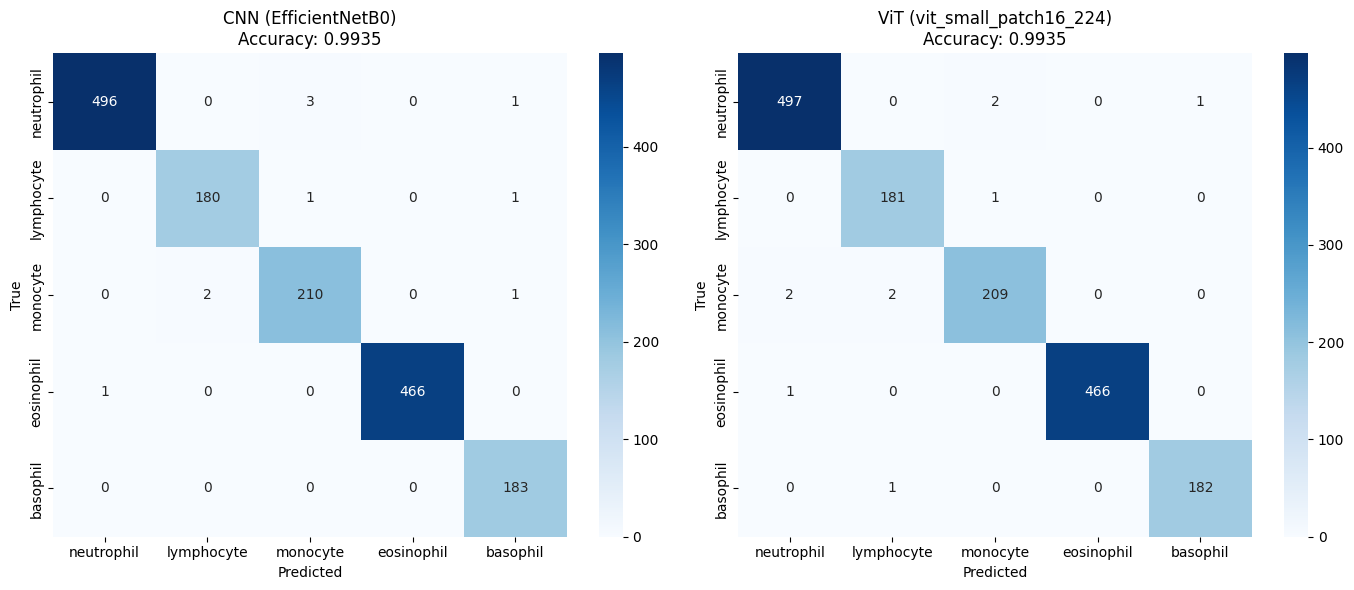

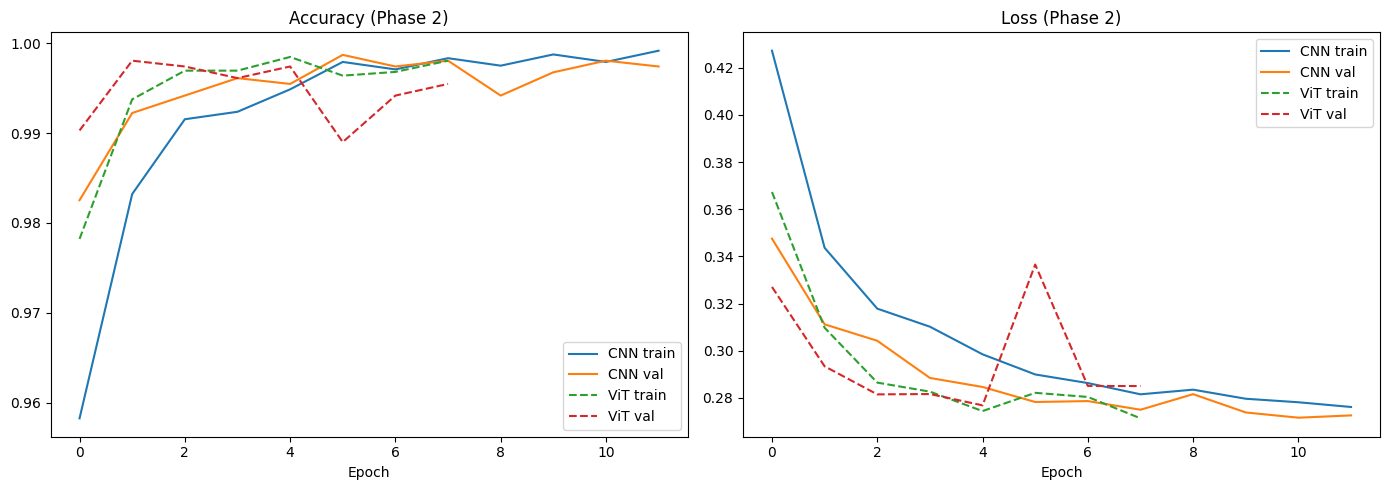

In [ ]:
# 10b & 10c. Plot Confusion Matrices and Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, preds, title in [
    (axes[0], cnn_labels, cnn_preds, 'CNN (EfficientNetB0)'),
    (axes[1], vit_labels, vit_preds, 'ViT (vit_small_patch16_224)')]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(labels, preds):.4f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_p2['train_acc'], label='CNN train'); axes[0].plot(hist_p2['val_acc'], label='CNN val')
axes[0].plot(hist_vit_p2['train_acc'], label='ViT train', linestyle='--'); axes[0].plot(hist_vit_p2['val_acc'], label='ViT val', linestyle='--')
axes[0].set_title('Accuracy (Phase 2)'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(hist_p2['train_loss'], label='CNN train'); axes[1].plot(hist_p2['val_loss'], label='CNN val')
axes[1].plot(hist_vit_p2['train_loss'], label='ViT train', linestyle='--'); axes[1].plot(hist_vit_p2['val_loss'], label='ViT val', linestyle='--')
axes[1].set_title('Loss (Phase 2)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


## 11. Explainability — Grad-CAM Analysis
Generate Grad-CAM heatmaps for both architectures to interpret feature reliance (nucleus vs. granules vs. background).


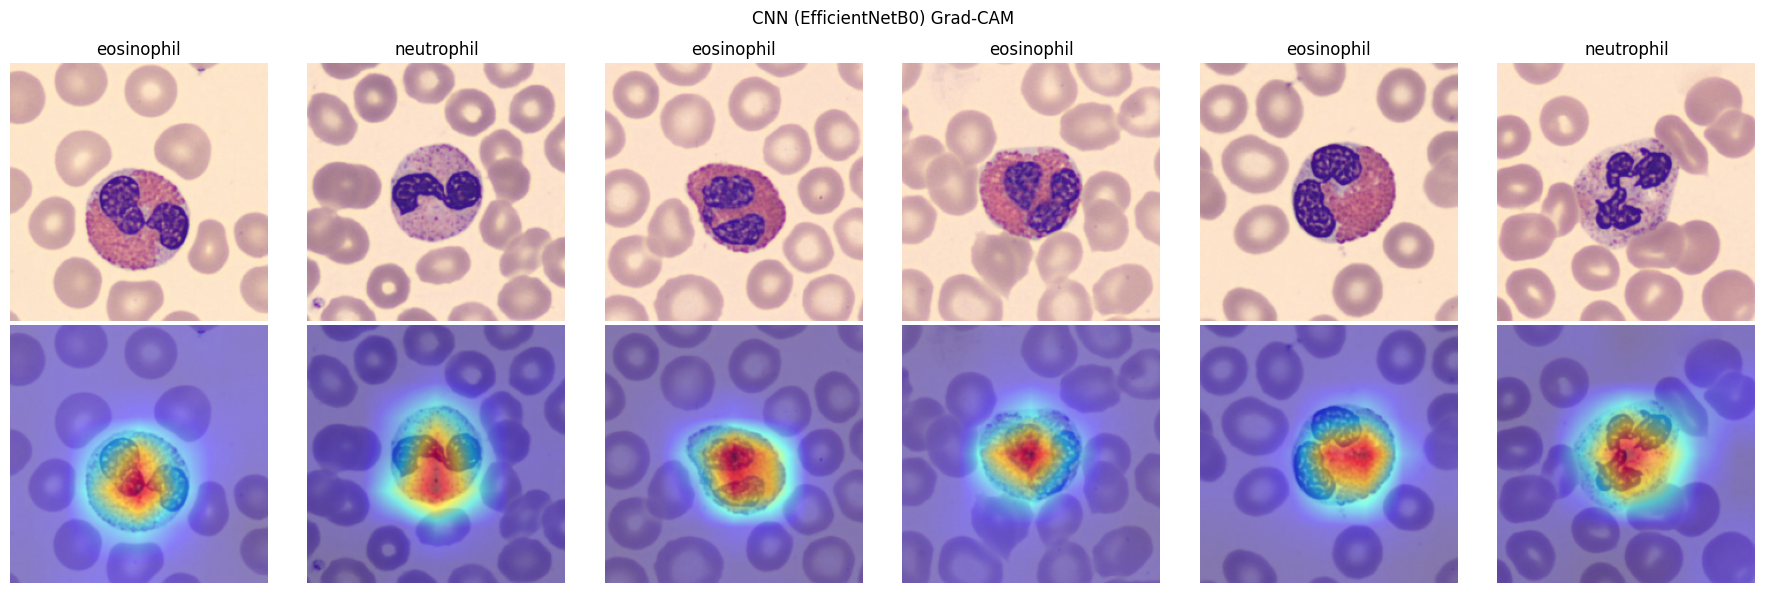

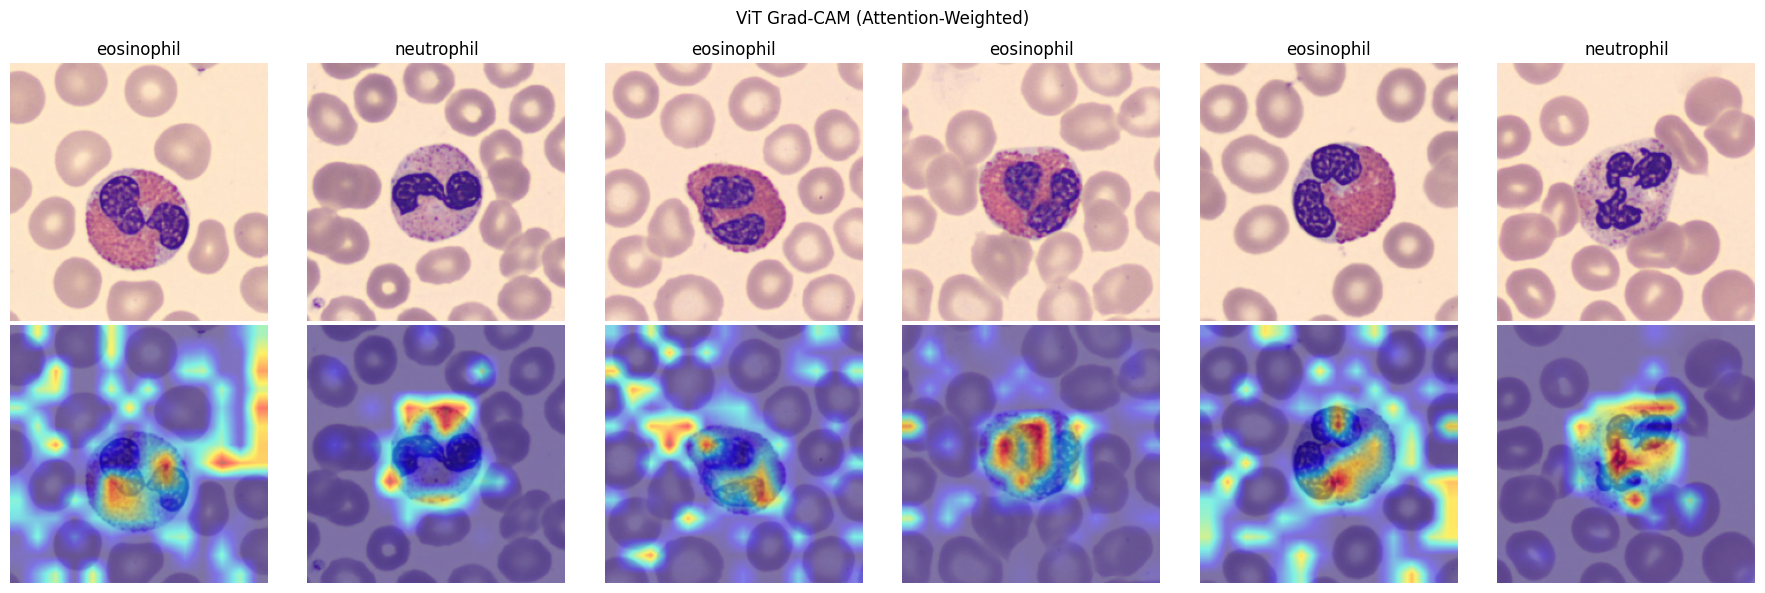

In [ ]:
# 11a & 11b. Grad-CAM for CNN and ViT
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

# CNN Grad-CAM
cnn_cam = GradCAM(model=cnn_model, target_layers=[cnn_model.features[-1]])
sample_x, sample_y = next(iter(test_dl))
sample_x = sample_x.to(device)

fig, axes = plt.subplots(2, 6, figsize=(18,6))
for i in range(6):
    input_tensor = sample_x[i:i+1]
    target = [ClassifierOutputTarget(sample_y[i].item())]
    grayscale_cam = cnn_cam(input_tensor=input_tensor, targets=target)[0]
    rgb_img = denormalize(sample_x[i])
    cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    axes[0,i].imshow(rgb_img); axes[0,i].set_title(TARGET_CLASSES[sample_y[i]]); axes[0,i].axis('off')
    axes[1,i].imshow(cam_img); axes[1,i].axis('off')
plt.suptitle('CNN (EfficientNetB0) Grad-CAM')
plt.tight_layout()
plt.savefig('cnn_gradcam.png', dpi=150)
plt.show()

# ViT Grad-CAM
def vit_reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)

vit_cam = GradCAM(model=vit_model, target_layers=[vit_model.blocks[-1].norm1], reshape_transform=vit_reshape_transform)

fig, axes = plt.subplots(2, 6, figsize=(18,6))
for i in range(6):
    input_tensor = sample_x[i:i+1]
    target = [ClassifierOutputTarget(sample_y[i].item())]
    grayscale_cam = vit_cam(input_tensor=input_tensor, targets=target)[0]
    rgb_img = denormalize(sample_x[i])
    cam_img = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    axes[0,i].imshow(rgb_img); axes[0,i].set_title(TARGET_CLASSES[sample_y[i]]); axes[0,i].axis('off')
    axes[1,i].imshow(cam_img); axes[1,i].axis('off')
plt.suptitle('ViT Grad-CAM (Attention-Weighted)')
plt.tight_layout()
plt.savefig('vit_gradcam.png', dpi=150)
plt.show()


## 12. Save Artifacts for Subsequent Pipeline Models
Stores weights and summary statistics required for Model 4 (GAN augmentation evaluation).


In [ ]:
# 12. Save results summary & checkpoints
results_summary = {
    'cnn_test_accuracy': float(accuracy_score(cnn_labels, cnn_preds)),
    'cnn_test_macro_f1': float(f1_score(cnn_labels, cnn_preds, average='macro')),
    'vit_test_accuracy': float(accuracy_score(vit_labels, vit_preds)),
    'vit_test_macro_f1': float(f1_score(vit_labels, vit_preds, average='macro')),
    'classes': TARGET_CLASSES,
    'train_size': len(train_p), 'val_size': len(val_p), 'test_size': len(test_p),
}

with open('model1_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Summary Saved:")
print(json.dumps(results_summary, indent=2))


Summary Saved:
{
  "cnn_test_accuracy": 0.9935275080906149,
  "cnn_test_macro_f1": 0.9916801217181236,
  "vit_test_accuracy": 0.9935275080906149,
  "vit_test_macro_f1": 0.992012831556111,
  "classes": [
    "neutrophil",
    "lymphocyte",
    "monocyte",
    "eosinophil",
    "basophil"
  ],
  "train_size": 7208,
  "val_size": 1545,
  "test_size": 1545
}
